# 05 — program sites

**What this notebook does.** Puts three different "a service is meant to be here" lists into
**one tidy table, one row per site**, tagged by `source`:

| `source` | what a row is | what it tells us |
|---|---|---|
| `mbsp` | a Mobile Black Spot Program funded base station | government money has been committed here — built or not yet |
| `guide` | an entry in the NT mobile coverage guide ("a GUIDE only") | the guide's own macro / small / proximity coverage read for a named place |
| `rict` | a RICT community phone / Wi-Fi site | a last-resort public phone or public Wi-Fi point |

These are **claims and commitments, not measurements**. nb 06 measures each village's
distance to the nearest of these and compares the guide's claim to the ACMA tower reality.

**What it reads** (raw / external only):

| dataframe | file |
|---|---|
| `mbsp_placemarks_df` | `external/mbsp/MBSP - Round *.kml` (8 files) |
| `coverage_guide_raw_df` | `raw/nt_mobile_coverage/mobile-coverage-all-sites.xlsx` |
| `rict_communities_df` | `raw/rict/Com_RICT_Community_NIAA_2024.json` |

**STAND is not read** — dropped from the pipeline (no unique signal).

**What it writes** (`data/processed/`):

| file | one row is | key |
|---|---|---|
| `program_sites.csv` | one program site | `program_site_id` (`mbsp-<MBSP_ID>` / `guide-<name-slug>` / `rict-<objectid>`) |
| `program_sites.geojson` | same, as points (EPSG:4326) | `program_site_id` |

**Decisions carried in** (`PROJECT_CONTEXT.md` §11):
- **MBSP** `site_type` → `macro` / `small` / `micro` (mapping shown in step 1); `mbsp_built`
  from `Site_Status == Complete`; dedupe on `MBSP_ID`.
- **guide** carries `guide_macro/small/proximity`, `guide_place_type`, `guide_population`
  (**reference only, never a population**).
- **RICT** — all four `site_type` codes count as public access; nb 05 carries the raw code
  as `rict_site_type` and decodes nothing. nb 06 turns RICT into `has_rict_public_access`
  (any RICT site within `RICT_MATCH_KM`) + `n_rict_sites`.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import json
import glob
import re
import xml.etree.ElementTree as ET
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [2]:
# Every file the notebook needs is read here. The MBSP KML parse and the xlsx header hunt
# are preprocessing of a raw read — the raw read still happens in this cell.

MBSP_GLOB           = "data/external/mbsp/MBSP - Round *.kml"
COVERAGE_GUIDE_XLSX = "data/raw/nt_mobile_coverage/mobile-coverage-all-sites.xlsx"
RICT_JSON           = "data/raw/rict/Com_RICT_Community_NIAA_2024.json"
KML_NS = {"k": "http://www.opengis.net/kml/2.2"}

# --- MBSP: every placemark from every round into one raw frame (round tagged, nothing
#     deduped or renamed yet; each site is listed twice per file) ---
_mbsp_rows = []
for _path in sorted(glob.glob(MBSP_GLOB)):
    _round = _path.split(" - ")[1].replace(" Funded Base Stations.kml", "")
    for _pm in ET.parse(_path).findall(".//k:Placemark", KML_NS):
        _f = {sd.get("name"): sd.text for sd in _pm.findall(".//k:SimpleData", KML_NS)}
        _coord = _pm.find(".//k:coordinates", KML_NS)
        if _coord is not None and _coord.text:
            _lon, _lat = _coord.text.strip().split()[0].split(",")[:2]
            _f["_lon"], _f["_lat"] = float(_lon), float(_lat)
        _f["_round"] = _round
        _mbsp_rows.append(_f)
mbsp_placemarks_df = pd.DataFrame(_mbsp_rows)

# --- coverage guide: raw, no header (row 0 is a banner); header row found in step 2 ---
coverage_guide_raw_df = pd.read_excel(COVERAGE_GUIDE_XLSX, header=None)

# --- RICT: FeatureCollection of points; properties into a frame ---
with open(RICT_JSON, encoding="utf-8") as fh:
    _rict = json.load(fh)
rict_communities_df = pd.DataFrame([f["properties"] for f in _rict["features"]])

OUT_DIR = Path("data/processed"); OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_PLOT_DIR = Path("docs/eda"); EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print(f"mbsp_placemarks_df    : {len(mbsp_placemarks_df)} placemarks (all rounds, all states, pre-dedupe)")
print(f"coverage_guide_raw_df : {len(coverage_guide_raw_df)} rows (raw, header not yet applied)")
print(f"rict_communities_df   : {len(rict_communities_df)} rows (all states)")

mbsp_placemarks_df    : 2710 placemarks (all rounds, all states, pre-dedupe)
coverage_guide_raw_df : 193 rows (raw, header not yet applied)
rict_communities_df   : 535 rows (all states)


## 1. MBSP — funded base stations

NT only, deduped on `MBSP_ID` (first copy wins). Site type comes from `Base_Station_Type`
(rounds 1–6) or `Solution_type` (round 7); `mbsp_built` from `Site_Status == "Complete"`.

In [3]:
MBSP_SITE_TYPE_MAP = {
    "Macro cell": "macro", "Macrocell": "macro",
    "Small cell": "small", "Small Cell": "small",
    "Microcell": "micro",
}

mbsp_nt_df = mbsp_placemarks_df[mbsp_placemarks_df["State"] == "NT"].drop_duplicates("MBSP_ID").copy()
mbsp_nt_df["raw_site_type"] = mbsp_nt_df["Base_Station_Type"].fillna(mbsp_nt_df.get("Solution_type"))
mbsp_nt_df["mbsp_site_type"] = mbsp_nt_df["raw_site_type"].map(MBSP_SITE_TYPE_MAP)
mbsp_nt_df["mbsp_built"] = mbsp_nt_df["Site_Status"].str.strip().str.lower().eq("complete")
mbsp_nt_df["mbsp_round"] = mbsp_nt_df["_round"]
mbsp_nt_df["name"] = mbsp_nt_df["Location"].fillna(mbsp_nt_df.get("Solution_name"))
mbsp_nt_df["latitude"]  = mbsp_nt_df["_lat"]
mbsp_nt_df["longitude"] = mbsp_nt_df["_lon"]

print(f"MBSP placemarks -> NT -> deduped on MBSP_ID: {len(mbsp_placemarks_df)} -> "
      f"{int((mbsp_placemarks_df['State'] == 'NT').sum())} -> {len(mbsp_nt_df)}")

MBSP placemarks -> NT -> deduped on MBSP_ID: 2710 -> 98 -> 49


### Validate: the site_type mapping, rounds, and built status

In [4]:
print("raw site_type -> normalised (the 5 spellings -> 3 categories):")
print(pd.crosstab(mbsp_nt_df["raw_site_type"], mbsp_nt_df["mbsp_site_type"], dropna=False))
assert mbsp_nt_df["mbsp_site_type"].notna().all(), "an MBSP raw site_type did not map"

print("\nper round:")
print(mbsp_nt_df["mbsp_round"].value_counts().sort_index())
print("\nSite_Status -> mbsp_built:")
print(pd.crosstab(mbsp_nt_df["Site_Status"], mbsp_nt_df["mbsp_built"]))
print(f"\nbuilt {int(mbsp_nt_df['mbsp_built'].sum())} / not {int((~mbsp_nt_df['mbsp_built']).sum())}")
assert mbsp_nt_df["name"].notna().all(), "an MBSP site has no name"

raw site_type -> normalised (the 5 spellings -> 3 categories):
mbsp_site_type  macro  micro  small
raw_site_type                      
Macro cell          9      0      0
Macrocell           2      0      0
Microcell           0      5      0
Small Cell          0      0      9
Small cell          0      0     24

per round:
mbsp_round
Round 1     5
Round 2    15
Round 4    12
Round 5    10
Round 7     7
Name: count, dtype: int64

Site_Status -> mbsp_built:
mbsp_built   False  True 
Site_Status              
Complete         0     41
In Progress      8      0

built 41 / not 8


## 2. Coverage guide — the NT mobile coverage spreadsheet

Header is a few rows down. `guide_macro / guide_small / guide_proximity` are the guide's own
coverage flags; `guide_place_type` is COMMUNITY / HIGHWAY / TOURISM / VILLAGE;
`guide_population` is the guide's own figure — **reference only, never used as population**.

In [5]:
_hdr = coverage_guide_raw_df.index[
    coverage_guide_raw_df.iloc[:, 0].astype(str).str.strip() == "SITE NAME"][0]
guide_df = coverage_guide_raw_df.iloc[_hdr + 1:].copy()
guide_df.columns = [str(c).strip() for c in coverage_guide_raw_df.iloc[_hdr]]
guide_df = guide_df.dropna(how="all")

for col in ("MACRO CELL", "SMALL CELL", "PROXIMITY TO CELL"):
    guide_df[col] = guide_df[col].astype(str).str.strip().str.upper().eq("YES")
guide_df["latitude"]  = pd.to_numeric(guide_df["LATITUDE"], errors="coerce")
guide_df["longitude"] = pd.to_numeric(guide_df["LONGITUDE"], errors="coerce")

guide_clean_df = pd.DataFrame({
    "name":             guide_df["SITE NAME"].astype(str).str.strip(),
    "latitude":         guide_df["latitude"],
    "longitude":        guide_df["longitude"],
    "guide_place_type": guide_df["SITE TYPE"].astype(str).str.strip(),
    "guide_macro":      guide_df["MACRO CELL"],
    "guide_small":      guide_df["SMALL CELL"],
    "guide_proximity":  guide_df["PROXIMITY TO CELL"],
    "guide_population":  pd.to_numeric(guide_df["POPULATION"], errors="coerce").astype("Int64"),
})
print(f"header at row index {_hdr}; {len(guide_clean_df)} guide rows")
print(f"rows missing a coordinate: {int(guide_clean_df[['latitude','longitude']].isna().any(axis=1).sum())}")

header at row index 4; 188 guide rows
rows missing a coordinate: 0


### Validate the guide read

In [6]:
print("guide_place_type:")
print(guide_clean_df["guide_place_type"].value_counts())
print("\nmacro x small x proximity:")
print(guide_clean_df.groupby(["guide_macro", "guide_small", "guide_proximity"]).size())
print(f"\nrows with a guide_population figure: {int(guide_clean_df['guide_population'].notna().sum())} "
      f"(reference only)")

guide_place_type:
guide_place_type
COMMUNITY    148
HIGHWAY       17
TOURISM       15
VILLAGE        8
Name: count, dtype: int64

macro x small x proximity:
guide_macro  guide_small  guide_proximity
False        False        True               96
             True         False              29
                          True                1
True         False        False              56
                          True                1
             True         False               5
dtype: int64

rows with a guide_population figure: 155 (reference only)


## 3. RICT — community phones / Wi-Fi

NT only. All four `site_type` codes count as public access, so nothing is filtered on type;
`rict_site_type` carries the raw code and this notebook decodes nothing.
**UNVERIFIED likely meanings** (confirm against NIAA program docs before quoting):
`CP` community phone · `WP` Wi-Fi phone · `CPW` both · `WH` Wi-Fi hotspot.

In [7]:
rict_nt_df = rict_communities_df[rict_communities_df["state"] == "NT"].copy()
rict_nt_df["latitude"]  = pd.to_numeric(rict_nt_df["latitude"], errors="coerce")
rict_nt_df["longitude"] = pd.to_numeric(rict_nt_df["longitude"], errors="coerce")
rict_nt_df["name"] = rict_nt_df["community_name"].astype(str).str.strip()
rict_nt_df["rict_site_type"] = rict_nt_df["site_type"].astype(str).str.strip()

print(f"RICT rows -> NT: {len(rict_communities_df)} -> {len(rict_nt_df)} "
      f"(the one row with state 'a' is WA by coordinates, excluded)")
print("\nrict_site_type (NT):")
print(rict_nt_df["rict_site_type"].value_counts())
print(f"\ndistinct community_name: {rict_nt_df['name'].nunique()}  "
      f"({int(rict_nt_df['name'].duplicated().sum())} communities have >1 RICT site)")
print(f"rows missing a coordinate: {int(rict_nt_df[['latitude','longitude']].isna().any(axis=1).sum())}")

RICT rows -> NT: 535 -> 296 (the one row with state 'a' is WA by coordinates, excluded)

rict_site_type (NT):
rict_site_type
WP     154
CP     106
CPW     23
WH      13
Name: count, dtype: int64

distinct community_name: 258  (38 communities have >1 RICT site)
rows missing a coordinate: 0


## 4. Assemble `program_sites.csv`

Each source contributes rows with the common 5 columns plus its own prefixed columns; the
other sources' columns are `NaN`. `program_site_id` is `mbsp-<MBSP_ID>` /
`guide-<name-slug>` / `rict-<objectid>` and must be globally unique. The guide slug is the
site name lowercased with every run of non-alphanumeric characters turned into `-` and the
ends trimmed (e.g. "Ali Curung" -> `guide-ali-curung`).

In [8]:
def slugify(text):
    return re.sub(r"[^a-z0-9]+", "-", str(text).lower()).strip("-")

mbsp_out = mbsp_nt_df.assign(
    program_site_id="mbsp-" + mbsp_nt_df["MBSP_ID"].astype(str),
    source="mbsp",
)[["program_site_id", "source", "name", "latitude", "longitude",
   "mbsp_site_type", "mbsp_built", "mbsp_round"]]

guide_out = guide_clean_df.reset_index(drop=True).assign(
    program_site_id=lambda d: "guide-" + d["name"].map(slugify),
    source="guide",
)[["program_site_id", "source", "name", "latitude", "longitude",
   "guide_place_type", "guide_macro", "guide_small", "guide_proximity", "guide_population"]]
assert (guide_out["program_site_id"] != "guide-").all(), "a guide name slugified to empty"
assert guide_out["program_site_id"].is_unique, "two guide sites produced the same name slug"

rict_out = rict_nt_df.assign(
    program_site_id="rict-" + rict_nt_df["objectid"].astype(str),
    source="rict",
)[["program_site_id", "source", "name", "latitude", "longitude", "rict_site_type"]]

PROGRAM_SITE_COLUMNS = [
    "program_site_id", "source", "name", "latitude", "longitude",
    "mbsp_site_type", "mbsp_built", "mbsp_round",
    "guide_place_type", "guide_macro", "guide_small", "guide_proximity", "guide_population",
    "rict_site_type",
]
program_sites_df = (pd.concat([mbsp_out, guide_out, rict_out], ignore_index=True)
                    .reindex(columns=PROGRAM_SITE_COLUMNS)
                    .sort_values(["source", "program_site_id"]).reset_index(drop=True))

assert list(program_sites_df.columns) == PROGRAM_SITE_COLUMNS, "column set / order changed"
assert program_sites_df["program_site_id"].is_unique, "program_site_id is not globally unique"
assert program_sites_df["latitude"].notna().all() and program_sites_df["longitude"].notna().all(), \
    "a program site has no coordinate"
assert program_sites_df["latitude"].between(-26.5, -10.0).all(), "a program site is outside NT latitudes"
assert program_sites_df["longitude"].between(128.5, 138.5).all(), "a program site is outside NT longitudes"
print(program_sites_df["source"].value_counts())
program_sites_df.head()

source
rict     296
guide    188
mbsp      49
Name: count, dtype: int64


,program_site_id,source,name,latitude,longitude,mbsp_site_type,mbsp_built,mbsp_round,guide_place_type,guide_macro,guide_small,guide_proximity,guide_population,rict_site_type
0,guide-adelaide-river,guide,ADELAIDE RIVER,-13.23780,131.10473,NaN,NaN,NaN,VILLAGE,True,False,False,317,NaN
1,guide-aileron-station,guide,AILERON STATION,-22.50000,133.24500,NaN,NaN,NaN,HIGHWAY,False,False,True,<NA>,NaN
2,guide-alamirra,guide,ALAMIRRA,-11.06700,132.52800,NaN,NaN,NaN,COMMUNITY,False,False,True,5,NaN
3,guide-ali-curung,guide,ALI CURUNG,-21.00333,134.40694,NaN,NaN,NaN,COMMUNITY,True,False,False,394,NaN
4,guide-alpurrurulam,guide,ALPURRURULAM,-20.98417,137.84749,NaN,NaN,NaN,COMMUNITY,True,False,False,350,NaN


### Validate: row counts per source, before → after

In [9]:
print("MBSP  : {} placemarks -> {} NT -> {} deduped".format(
    len(mbsp_placemarks_df), int((mbsp_placemarks_df['State'] == 'NT').sum()), len(mbsp_out)))
print("guide : {} raw rows -> {} after header+dropna".format(
    len(coverage_guide_raw_df), len(guide_out)))
print("rict  : {} rows -> {} NT".format(len(rict_communities_df), len(rict_out)))
print(f"\nprogram_sites.csv total: {len(program_sites_df)}  "
      f"(mbsp {len(mbsp_out)} + guide {len(guide_out)} + rict {len(rict_out)})")

# per-source columns must be null for the other sources
for src, cols in [("mbsp", ["mbsp_site_type", "mbsp_round"]),
                  ("guide", ["guide_place_type"]),
                  ("rict", ["rict_site_type"])]:
    off = program_sites_df.loc[program_sites_df["source"] != src, cols].notna().any(axis=1).sum()
    print(f"{src:6s} columns non-null on other sources' rows: {int(off)}  (should be 0)")

MBSP  : 2710 placemarks -> 98 NT -> 49 deduped
guide : 193 raw rows -> 188 after header+dropna
rict  : 535 rows -> 296 NT

program_sites.csv total: 533  (mbsp 49 + guide 188 + rict 296)
mbsp   columns non-null on other sources' rows: 0  (should be 0)
guide  columns non-null on other sources' rows: 0  (should be 0)
rict   columns non-null on other sources' rows: 0  (should be 0)


## 5. Validation maps — by source, and MBSP built vs not built

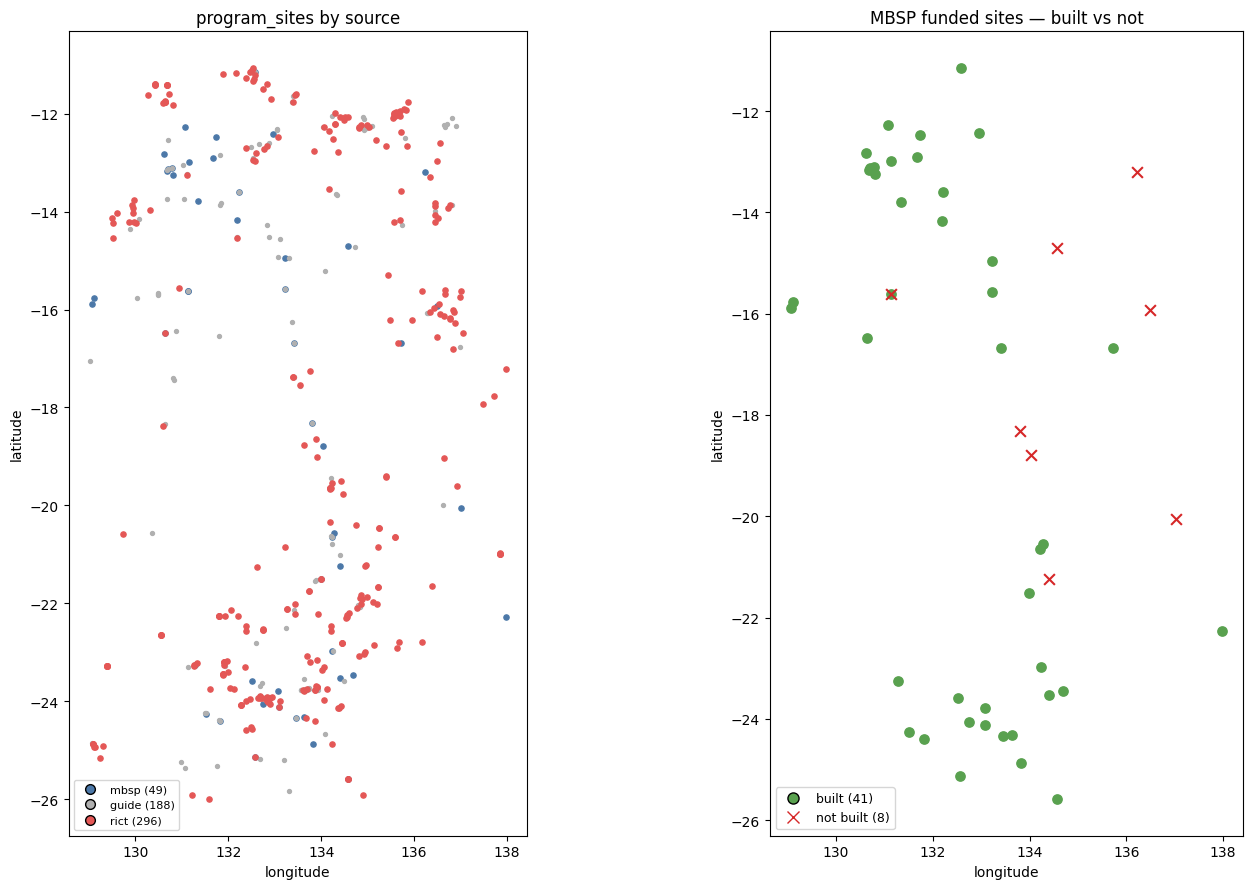

In [10]:
program_sites_gdf = gpd.GeoDataFrame(
    program_sites_df.copy(),
    geometry=gpd.points_from_xy(program_sites_df["longitude"], program_sites_df["latitude"]),
    crs="EPSG:4326")

SOURCE_COLOUR = {"mbsp": "#4c78a8", "guide": "#b0b0b0", "rict": "#e45756"}
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

for src, colour in SOURCE_COLOUR.items():
    sub = program_sites_gdf[program_sites_gdf["source"] == src]
    sub.plot(ax=axes[0], color=colour, markersize=(14 if src != "guide" else 8))
axes[0].legend(handles=[Line2D([], [], marker="o", color="none", markerfacecolor=c, markersize=7,
                               label=f"{s} ({int((program_sites_df['source'] == s).sum())})")
                        for s, c in SOURCE_COLOUR.items()], fontsize=8, loc="lower left")
axes[0].set_title("program_sites by source")
axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")

mbsp_gdf = program_sites_gdf[program_sites_gdf["source"] == "mbsp"]
mbsp_gdf[mbsp_gdf["mbsp_built"]].plot(ax=axes[1], color="#59a14f", markersize=45)
mbsp_gdf[~mbsp_gdf["mbsp_built"].astype(bool)].plot(ax=axes[1], color="#d62728", marker="x", markersize=60)
axes[1].legend(handles=[
    Line2D([], [], marker="o", color="none", markerfacecolor="#59a14f", markersize=8,
           label=f"built ({int(mbsp_gdf['mbsp_built'].sum())})"),
    Line2D([], [], marker="x", color="#d62728", linestyle="none", markersize=8,
           label=f"not built ({int((~mbsp_gdf['mbsp_built'].astype(bool)).sum())})"),
], fontsize=9, loc="lower left")
axes[1].set_title("MBSP funded sites — built vs not")
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
fig.tight_layout()
eda_figures["05_program_sites_by_source"] = fig

In [11]:
# Second-to-last cell: summary print.
print("05_program_sites — summary")
print("-" * 60)
print(f"rows out : {len(program_sites_df)}  (mbsp {len(mbsp_out)}, guide {len(guide_out)}, rict {len(rict_out)})")
print(f"mbsp     : {int(mbsp_nt_df['mbsp_built'].sum())} built / {int((~mbsp_nt_df['mbsp_built']).sum())} not; "
      f"types {mbsp_nt_df['mbsp_site_type'].value_counts().to_dict()}")
print(f"guide    : place types {guide_clean_df['guide_place_type'].value_counts().to_dict()}")
print(f"rict     : site types {rict_nt_df['rict_site_type'].value_counts().to_dict()}")
print("dropped  : STAND (not read); the 1 RICT row with state 'a' (WA)")
print("asserts  : program_site_id globally unique, coords present & in NT box, "
      "per-source columns null elsewhere, MBSP site_type fully mapped")

05_program_sites — summary
------------------------------------------------------------
rows out : 533  (mbsp 49, guide 188, rict 296)
mbsp     : 41 built / 8 not; types {'small': 33, 'macro': 11, 'micro': 5}
guide    : place types {'COMMUNITY': 148, 'HIGHWAY': 17, 'TOURISM': 15, 'VILLAGE': 8}
rict     : site types {'WP': 154, 'CP': 106, 'CPW': 23, 'WH': 13}
dropped  : STAND (not read); the 1 RICT row with state 'a' (WA)
asserts  : program_site_id globally unique, coords present & in NT box, per-source columns null elsewhere, MBSP site_type fully mapped


In [12]:
# Last cell: every file write.
csv_path     = OUT_DIR / "program_sites.csv"
geojson_path = OUT_DIR / "program_sites.geojson"

program_sites_df.to_csv(csv_path, index=False)
gpd.GeoDataFrame(
    program_sites_df.copy(),
    geometry=gpd.points_from_xy(program_sites_df["longitude"], program_sites_df["latitude"]),
    crs="EPSG:4326",
).to_file(geojson_path, driver="GeoJSON")

for name, fig in eda_figures.items():
    fig.savefig(EDA_PLOT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", csv_path, f"({len(program_sites_df)} rows)")
print(" ", geojson_path)
for name in eda_figures:
    print("  docs/eda/" + name + ".png")

wrote:
  data\processed\program_sites.csv (533 rows)
  data\processed\program_sites.geojson
  docs/eda/05_program_sites_by_source.png
